<a href="https://colab.research.google.com/github/Ajay17K/fake_news_detection/blob/main/Fake_News_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
fake = pd.read_csv('/content/drive/MyDrive/Dataset/Fake.csv')
true = pd.read_csv('/content/drive/MyDrive/Dataset/True.csv')

In [11]:
#dataset preview

fake.head()
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [12]:
#Information
fake.info()
true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [13]:
fake.isnull().sum()
true.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [14]:
#make labels
fake["class"]=0
true["class"]=1

In [15]:
#RemoveLast 10 Rows for Manual Testing
fake_manual=fake.tail(10).copy()
true_manual=true.tail(10).copy()
fake=fake.iloc[:-10]
true=true.iloc[:-10]

In [16]:
#Merge Manual Dataset
manual_testing = pd.concat([fake_manual, true_manual], axis=0)
manual_testing.to_csv("manual_testing.csv", index=False)

In [17]:
#Merge Training Dataset
data = pd.concat([fake, true], axis=0)
data = data.sample(frac=1).reset_index(drop=True)

In [18]:
print(data.shape)

(44878, 5)


In [19]:
#RemoveColumns
data = data.drop(["title","subject","date"], axis=1)

In [20]:
#Text Cleaning Function
import re
import string
def clean_text(text):
  text = text.lower()
  text = re.sub(r'\[.*?\]', '', text)
  text = re.sub(r'https?://\S+|www\.\S+', '', text)
  text = re.sub(r'<.*?>+', '', text)
  text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
  text = re.sub(r'\n', '', text)
  text = re.sub(r'\w*\d\w*', '', text)

  return text

data['text'] = data["text"].apply(clean_text)


In [21]:
#Split Features
X=data['text']
Y=data['class']

In [22]:
#Train-Test
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25 ,random_state=42)

In [23]:
#Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(stop_words='english',max_features=50000,ngram_range=(1,2))
X_train=vectorizer.fit_transform(X_train)
X_test=vectorizer.transform(X_test)

In [24]:
#LR
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
LR = LogisticRegression()
LR.fit(X_train,Y_train)

pred_lr = LR.predict(X_test)
print("Accuracy:-",accuracy_score(Y_test,pred_lr))
print(classification_report(Y_test,pred_lr))

Accuracy:- 0.9888591800356507
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5938
           1       0.99      0.99      0.99      5282

    accuracy                           0.99     11220
   macro avg       0.99      0.99      0.99     11220
weighted avg       0.99      0.99      0.99     11220



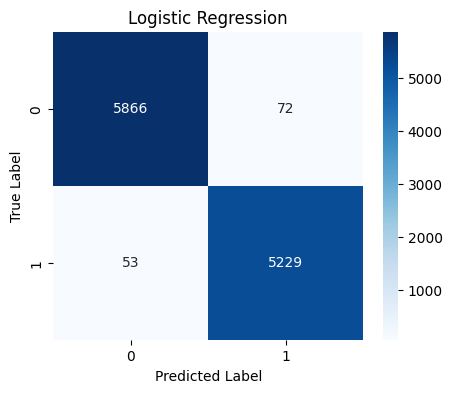

In [25]:
#Confusion Matrix Logistic Regression
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test,pred_lr)
plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression')
plt.show()

In [26]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier()
DT.fit(X_train,Y_train)

pred_dt = DT.predict(X_test)
print("Accuracy:-",accuracy_score(Y_test,pred_dt))
print(classification_report(Y_test,pred_dt))


Accuracy:- 0.9950089126559715
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      5938
           1       1.00      0.99      0.99      5282

    accuracy                           1.00     11220
   macro avg       1.00      0.99      0.99     11220
weighted avg       1.00      1.00      1.00     11220



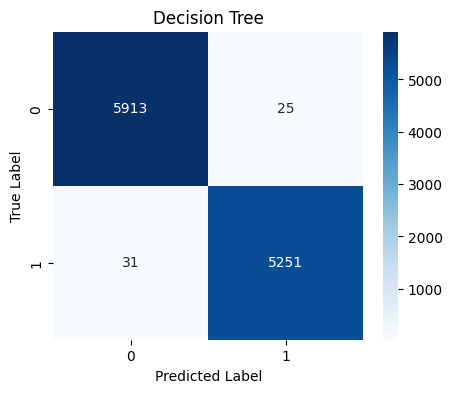

In [27]:
##Confusion Matrix Decision Tree
cm_dt = confusion_matrix(Y_test,pred_dt)
plt.figure(figsize=(5,4))

sns.heatmap(cm_dt,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Decision Tree')
plt.show()

In [28]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(n_estimators=100, random_state=42)
RF.fit(X_train,Y_train)

pred_rf = RF.predict(X_test)
print("Accuracy:-",accuracy_score(Y_test,pred_rf))
print(classification_report(Y_test,pred_rf))

Accuracy:- 0.9950980392156863
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5938
           1       0.99      1.00      0.99      5282

    accuracy                           1.00     11220
   macro avg       1.00      1.00      1.00     11220
weighted avg       1.00      1.00      1.00     11220



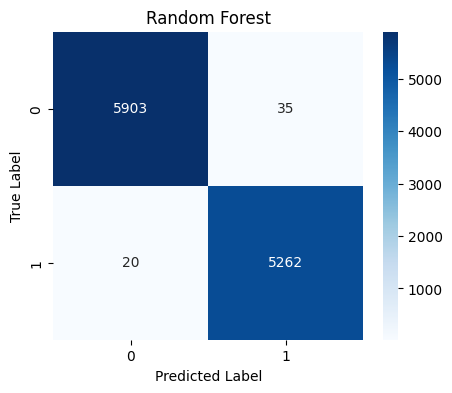

In [29]:
#Confusion Matrix Random Forest
cm_rf = confusion_matrix(Y_test,pred_rf)
plt.figure(figsize=(5,4))

sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest')
plt.show()

In [30]:
#Accuracy Comparison
accuracy_scores = pd.DataFrame({'Model': ['Logistic Regression',
                                          'Decision Tree',
                                          'Random Forest'],
                               'Accuracy': [accuracy_score(Y_test, pred_lr),
                                            accuracy_score(Y_test, pred_dt),
                                            accuracy_score(Y_test, pred_rf)]})

accuracy_scores


,Model,Accuracy
0,Logistic Regression,0.988859
1,Decision Tree,0.995009
2,Random Forest,0.995098


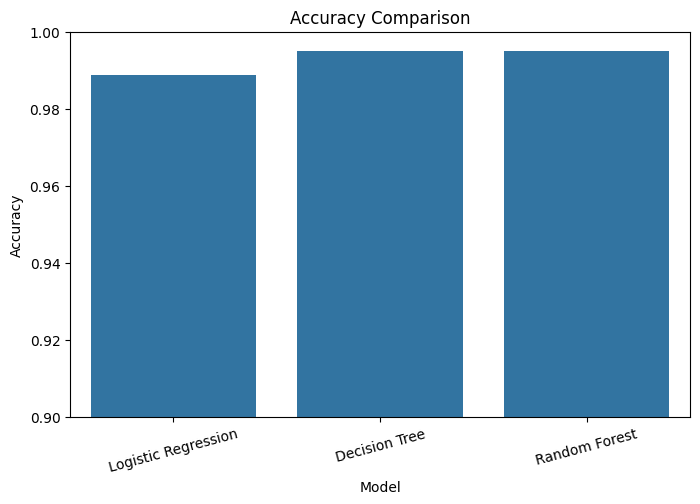

In [31]:
#Accuracy Graph
plt.figure(figsize=(8,5))
sns.barplot(x='Model',y='Accuracy',data=accuracy_scores)
plt.xlabel('Model')
plt.xticks(rotation=15)
plt.ylabel('Accuracy')
plt.ylim(0.9,1)
plt.title('Accuracy Comparison')
plt.show()

In [32]:
def output_lable(n):

  if n == 0:
      return "Fake News"
  else:
      return "Not A Fake News"

In [33]:
#Prediction Function
def manual_testing(news):
    testing_news = {"text":[news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"] = new_def_test["text"].apply(clean_text)
    new_x_test = vectorizer.transform(new_def_test["text"])
    pred_LR = LR.predict(new_x_test)
    pred_DT = DT.predict(new_x_test)
    pred_RF = RF.predict(new_x_test)

    return print(

        "\nLR Prediction :",output_lable(pred_LR[0]),

        "\nDT Prediction :",output_lable(pred_DT[0]),

        "\nRF Prediction :",output_lable(pred_RF[0])

    )

In [34]:
news = str(input())
manual_testing(news)

NASA successfully launched a new weather satellite into orbit.

LR Prediction : Fake News 
DT Prediction : Fake News 
RF Prediction : Fake News
